# 📓 Cuaderno 2: Análisis Exploratorio de Datos (EDA)
**Proyecto:** Predicción de Éxito Académico y Mitigación de Deserción Escolar
**Metodología:** CRISP-ML - Fase de Comprensión de los Datos

En este cuaderno exploramos la estructura estadística de la información limpia, visualizando las distribuciones de notas y analizando cómo influyen las inasistencias en la aprobación final del estudiante.

In [7]:
# Paso 1: Importar librerías de manipulación y visualización de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración por defecto de gráficos estilo Seaborn
sns.set_theme(style="whitegrid")
print("Librerías de visualización listas.")

Librerías de visualización listas.


### Paso 2: Carga y Revisión de Estructura
Cargamos la data previamente estructurada en la fase de ETL.

In [8]:
df = pd.read_csv('Resultados_Limpio.csv')

print("--- Información del Dataset ---")
df.info()

print("\n--- Resumen Estadístico Descriptivo ---")
df.describe()

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 840869 entries, 0 to 840868
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ano                  840869 non-null  int64  
 1   grado                840869 non-null  int64  
 2   intensidad_semannal  840869 non-null  int64  
 3   faltas               840869 non-null  int64  
 4   nota                 840869 non-null  float64
 5   refuerzo             840869 non-null  int64  
 6   target_binario       840869 non-null  int64  
dtypes: float64(1), int64(6)
memory usage: 44.9 MB

--- Resumen Estadístico Descriptivo ---


,ano,grado,intensidad_semannal,faltas,nota,refuerzo,target_binario
count,840869.000000,840869.000000,840869.000000,840869.000000,840869.000000,840869.000000,840869.000000
mean,2019.335910,6.053302,2.403430,0.600146,3.242920,0.052339,0.767751
std,2.864433,3.113669,1.665184,1.921392,1.330737,0.318341,0.422267
min,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,4.000000,1.000000,0.000000,3.000000,0.000000,1.000000
50%,2019.000000,6.000000,2.000000,0.000000,3.500000,0.000000,1.000000
75%,2022.000000,9.000000,4.000000,0.000000,4.100000,0.000000,1.000000
max,2024.000000,11.000000,7.000000,47.000000,10.000000,4.000000,1.000000


### Paso 3: Visualización Gráfica
Dibujamos gráficos interactivos directamente renderizados en las celdas del Notebook para el análisis clínico de las variables académicas.

/tmp/ipykernel_29503/4100565282.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binario', y='nota', ax=axes[0], palette='Set2')
/tmp/ipykernel_29503/4100565282.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Aprueba', 'Aprueba'])
/tmp/ipykernel_29503/4100565282.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='grado', y='faltas', ax=axes[1], palette='coolwarm', errorbar=None)


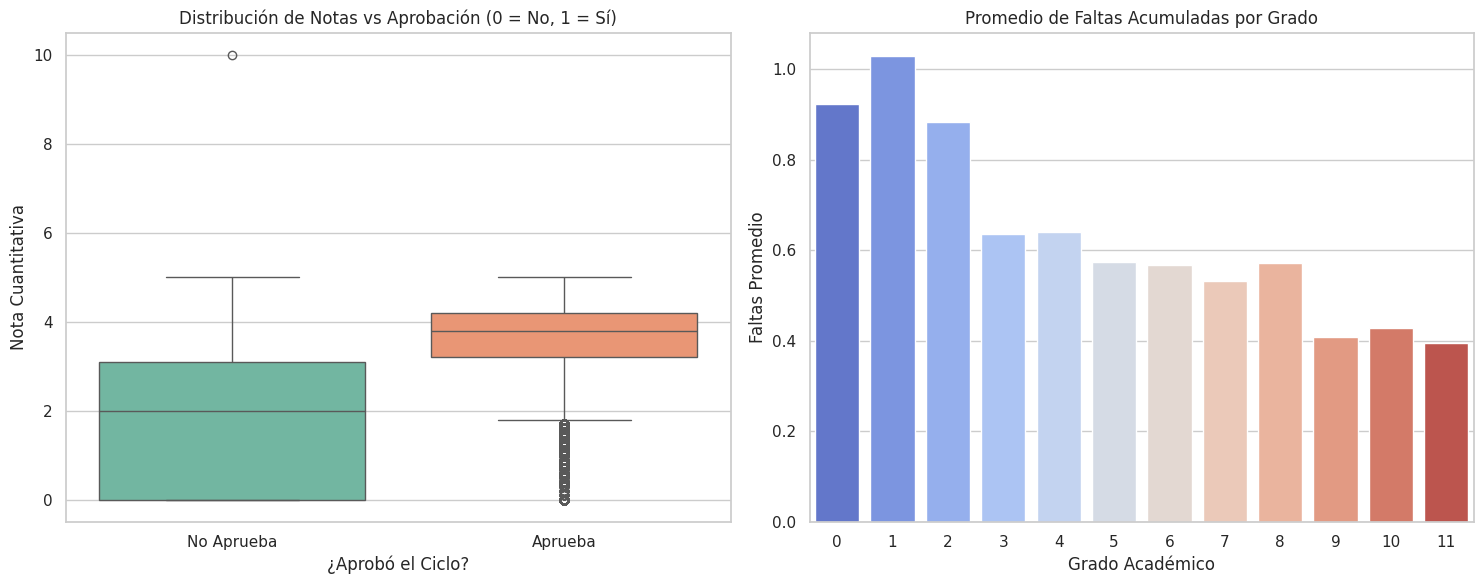

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de Cajas y Bigotes (Boxplot) para evaluar Outliers y Notas según el estado de promoción
sns.boxplot(data=df, x='target_binario', y='nota', ax=axes[0], palette='Set2')
axes[0].set_title('Distribución de Notas vs Aprobación (0 = No, 1 = Sí)')
axes[0].set_xlabel('¿Aprobó el Ciclo?')
axes[0].set_ylabel('Nota Cuantitativa')
axes[0].set_xticklabels(['No Aprueba', 'Aprueba'])

# 2. Gráfico de Barras para el volumen de inasistencias acumuladas promedio por Grado escolar
sns.barplot(data=df, x='grado', y='faltas', ax=axes[1], palette='coolwarm', errorbar=None)
axes[1].set_title('Promedio de Faltas Acumuladas por Grado')
axes[1].set_xlabel('Grado Académico')
axes[1].set_ylabel('Faltas Promedio')

plt.tight_layout()
plt.show()

### Paso 4: Matriz de Correlación Lineal
Evaluamos numéricamente la relación cruzada entre las variables numéricas.

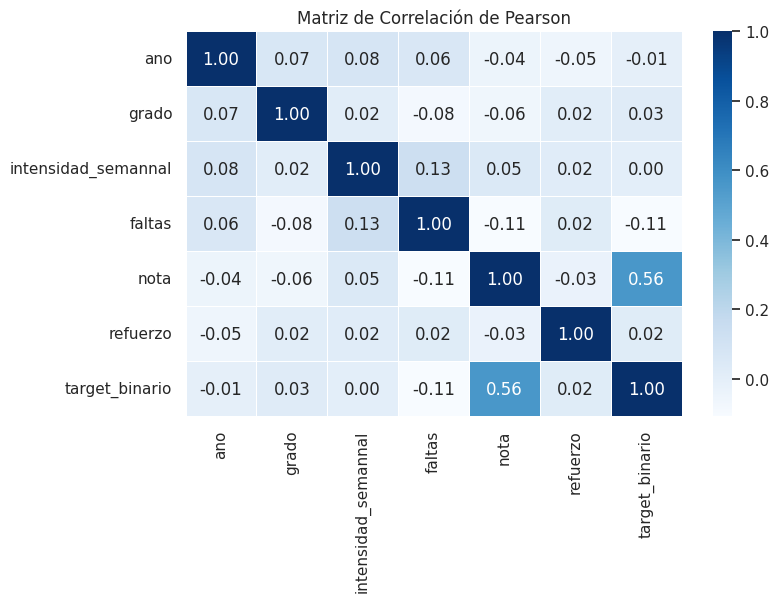

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Pearson')
plt.show()

### Paso 5: Análisis Detallado de Variables Individuales

Vamos a explorar la distribución de cada variable clave para entender mejor sus características.

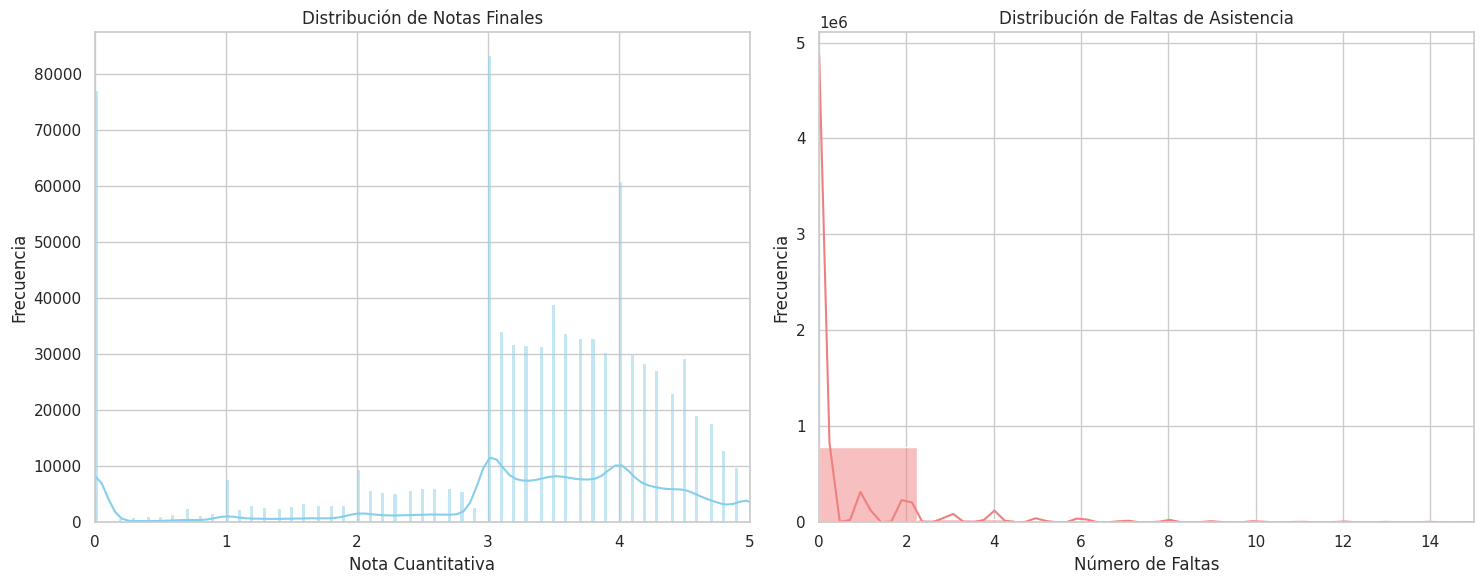

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histograma de Notas
sns.histplot(df['nota'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Notas Finales')
axes[0].set_xlabel('Nota Cuantitativa')
axes[0].set_ylabel('Frecuencia')
axes[0].set_xlim(0, 5) # Set x-axis limits from 0 to 5

# Histograma de Faltas
sns.histplot(df['faltas'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribución de Faltas de Asistencia')
axes[1].set_xlabel('Número de Faltas')
axes[1].set_ylabel('Frecuencia')
axes[1].set_xlim(0, 15) # Set x-axis limits from 0 to 15
plt.tight_layout()
plt.show()

/tmp/ipykernel_29503/3151795983.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='grado', ax=axes[0], palette='viridis', order=sorted(df['grado'].unique()))
/tmp/ipykernel_29503/3151795983.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='refuerzo', ax=axes[1], palette='plasma')
/tmp/ipykernel_29503/3151795983.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_29503/3151795983.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` a

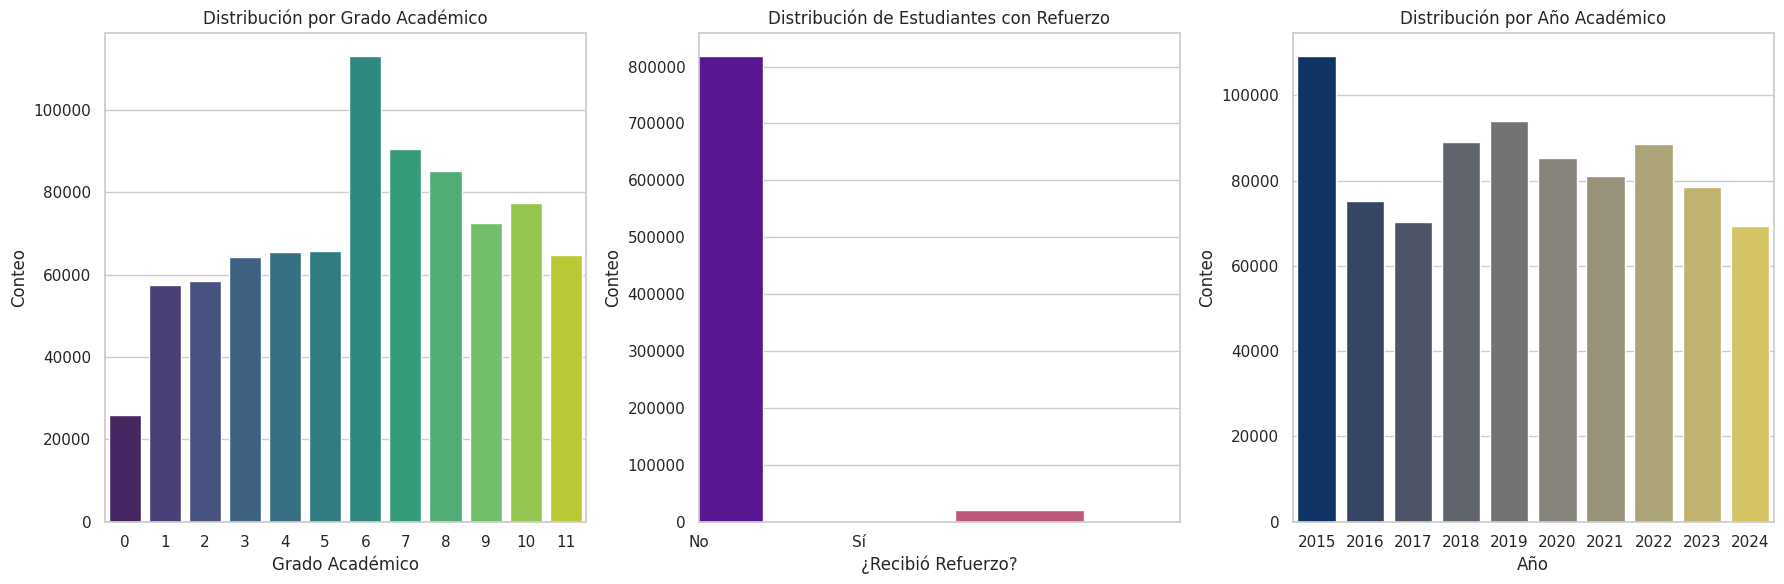

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Resultados_Limpio.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Conteo de Grado Académico
sns.countplot(data=df, x='grado', ax=axes[0], palette='viridis', order=sorted(df['grado'].unique()))
axes[0].set_title('Distribución por Grado Académico')
axes[0].set_xlabel('Grado Académico')
axes[0].set_ylabel('Conteo')

# Conteo de Refuerzo
sns.countplot(data=df, x='refuerzo', ax=axes[1], palette='plasma')
axes[1].set_title('Distribución de Estudiantes con Refuerzo')
axes[1].set_xlabel('¿Recibió Refuerzo?')
axes[1].set_ylabel('Conteo')
axes[1].set_xticklabels(['No', 'Sí'])
axes[1].set_xlim(0, 3) # Set x-axis limits from 0 to 3
# Conteo de Año
sns.countplot(data=df, x='ano', ax=axes[2], palette='cividis', order=sorted(df['ano'].unique())) # Corrected 'año' to 'ano'
axes[2].set_title('Distribución por Año Académico')
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Conteo')

plt.tight_layout()
plt.show()

### Paso 6: Análisis de Relaciones entre Variables

Ahora, investigaremos cómo se relacionan estas variables entre sí, enfocándonos en el impacto sobre la aprobación (target).

/tmp/ipykernel_29503/2979197594.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binario', y='faltas', ax=axes[0], palette='pastel')
/tmp/ipykernel_29503/2979197594.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No Aprueba', 'Aprueba'])
/tmp/ipykernel_29503/2979197594.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='grado', y='nota', ax=axes[1], palette='rocket', order=sorted(df['grado'].unique()))


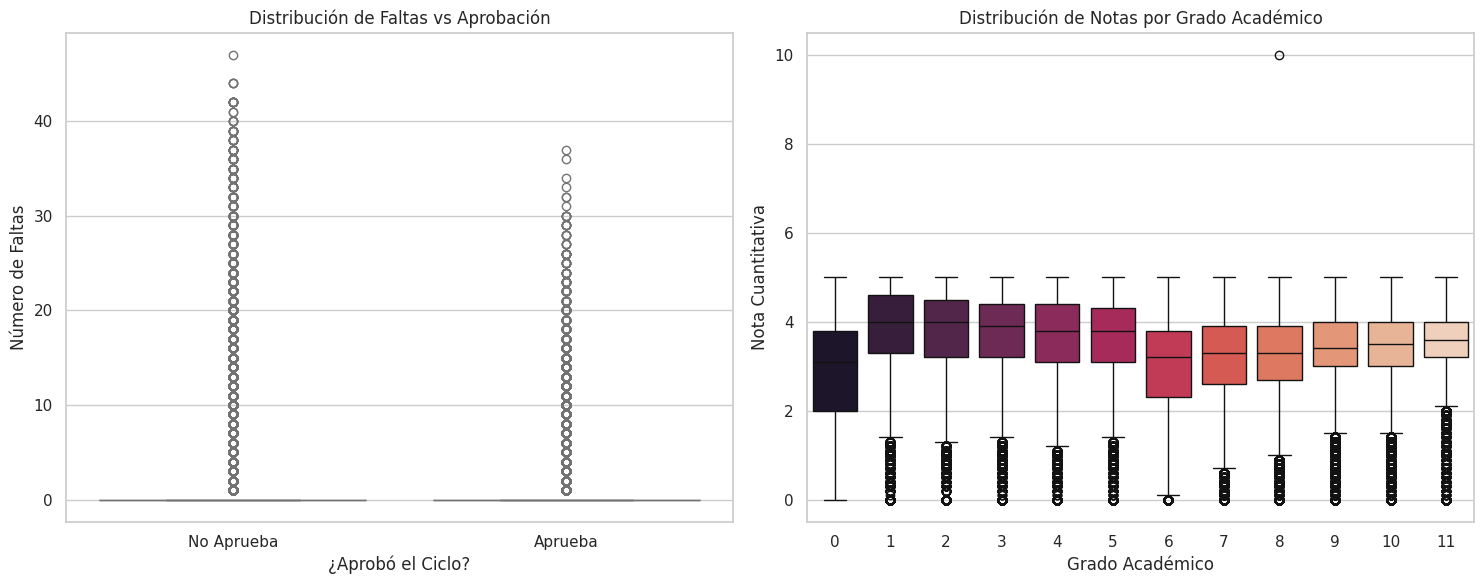

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Resultados_Limpio.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Faltas vs Aprobación
sns.boxplot(data=df, x='target_binario', y='faltas', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución de Faltas vs Aprobación')
axes[0].set_xlabel('¿Aprobó el Ciclo?')
axes[0].set_ylabel('Número de Faltas')
axes[0].set_xticklabels(['No Aprueba', 'Aprueba'])

# Boxplot: Grado vs Notas
sns.boxplot(data=df, x='grado', y='nota', ax=axes[1], palette='rocket', order=sorted(df['grado'].unique()))
axes[1].set_title('Distribución de Notas por Grado Académico')
axes[1].set_xlabel('Grado Académico')
axes[1].set_ylabel('Nota Cuantitativa')

plt.tight_layout()
plt.show()

/tmp/ipykernel_29503/1898800440.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='refuerzo', y='nota', ax=axes[0], palette='deep')
/tmp/ipykernel_29503/1898800440.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='refuerzo', y='faltas', ax=axes[1], palette='dark')


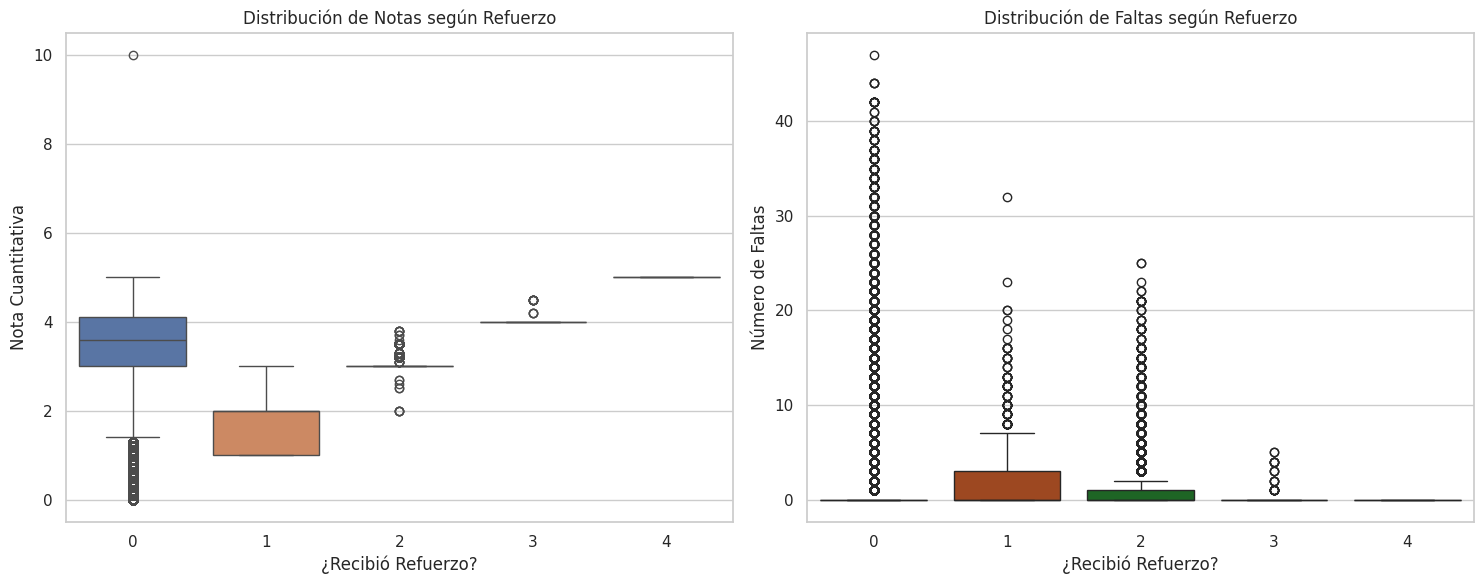

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Resultados_Limpio.csv')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot: Refuerzo vs Notas
sns.boxplot(data=df, x='refuerzo', y='nota', ax=axes[0], palette='deep')
axes[0].set_title('Distribución de Notas según Refuerzo')
axes[0].set_xlabel('¿Recibió Refuerzo?')
axes[0].set_ylabel('Nota Cuantitativa')

# Boxplot: Refuerzo vs Faltas
sns.boxplot(data=df, x='refuerzo', y='faltas', ax=axes[1], palette='dark')
axes[1].set_title('Distribución de Faltas según Refuerzo')
axes[1].set_xlabel('¿Recibió Refuerzo?')
axes[1].set_ylabel('Número de Faltas')

plt.tight_layout()
plt.show()

Los coeficientes de Gini son más comúnmente utilizados para medir la desigualdad en distribuciones de ingresos o riqueza. En el contexto de un Análisis Exploratorio de Datos general para estas variables académicas, las visualizaciones de distribución (histogramas, boxplots) y las matrices de correlación ofrecen una comprensión más directa y aplicable de los patrones y relaciones. Si se busca una medida de "desigualdad" o "dispersión" en variables específicas más allá de la desviación estándar, se podría considerar, pero para este conjunto de datos y los objetivos de EDA, las gráficas generadas son más informativas.

### Paso 7: Matriz de Correlación Ampliada (incluyendo el Target)

Vamos a generar una matriz de correlación de Pearson que incluya la variable `target_binario` para entender su relación lineal con las otras variables numéricas.

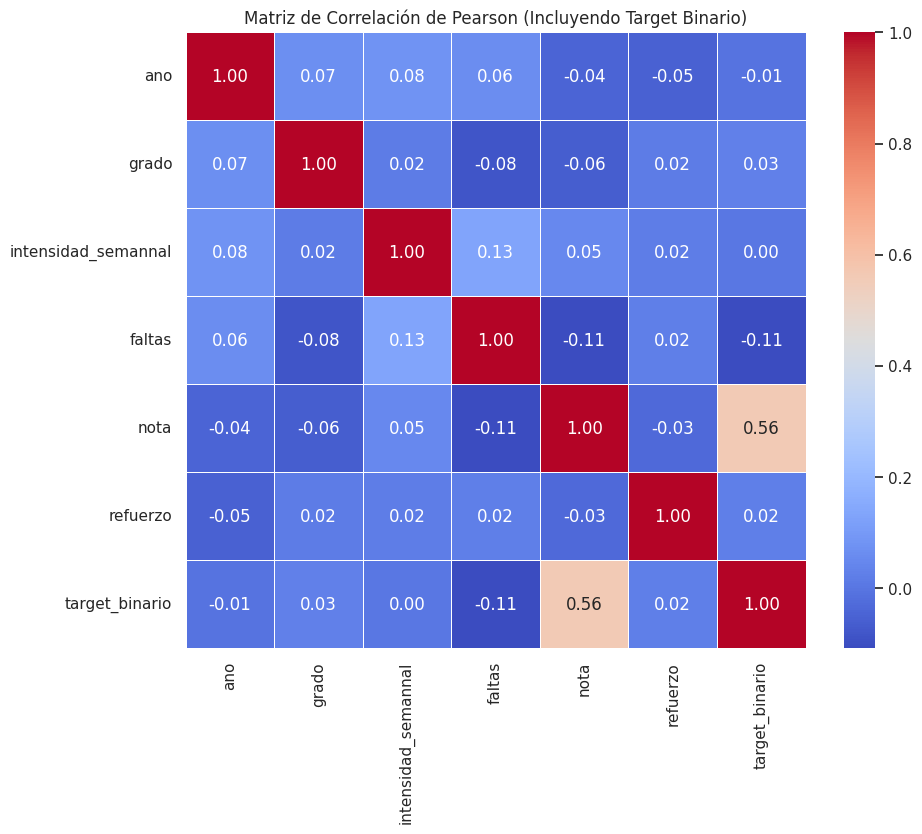

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Resultados_Limpio.csv')

numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix_extended = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_extended, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Pearson (Incluyendo Target Binario)')
plt.show()

### Paso 8: Correlación para Variables Categóricas (Cramer's V)

Para evaluar la asociación entre variables categóricas, utilizaremos el coeficiente V de Cramer, que es una medida de asociación basada en el estadístico chi-cuadrado.

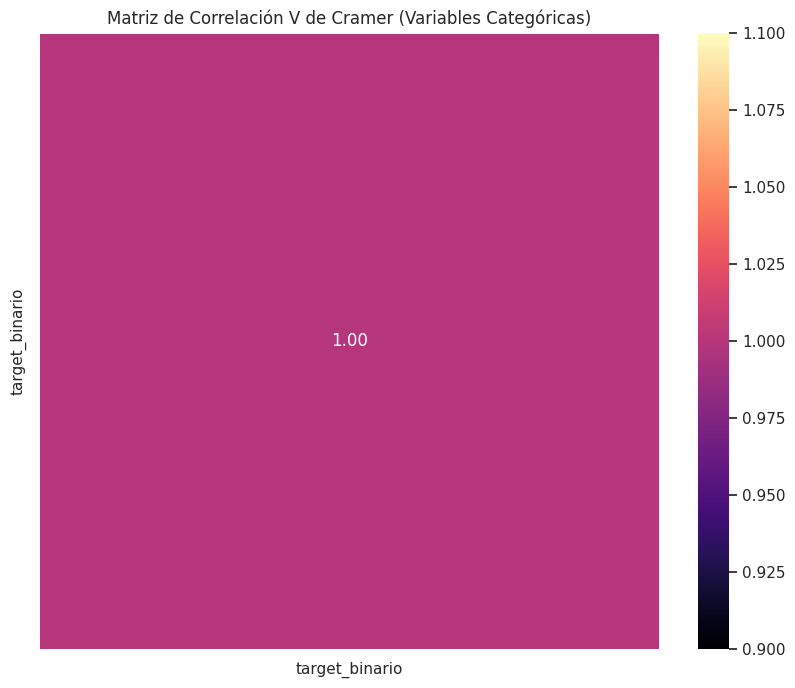

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Resultados_Limpio.csv')

import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    phi2 = chi2 / n
    v = np.sqrt(phi2 / min(r - 1, k - 1))
    return v

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.append('target_binario') # Assuming target_binario is also categorical for Cramer's V

cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        if col1 == col2:
            cramers_v_matrix.loc[col1, col2] = 1.0
        else:
            cramers_v_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_v_matrix.astype(float), annot=True, cmap='magma', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación V de Cramer (Variables Categóricas)")
plt.show()